# Federated Algorithm Comparison — Part 3: Combined Results

**Prerequisites:** Run both part notebooks first:
1. `federated_part1_fedavg_fedprox.ipynb` → saves `fl_outputs/part1_metrics.json`
2. `federated_part2_scaffold_fedadam.ipynb` → saves `fl_outputs/part2_metrics.json`

This notebook **loads both JSON files** and produces a full 4-algorithm comparison:
- Training loss curves per round
- Per-client training loss breakdown
- Final validation loss (bar chart)
- Summary statistics table

| Algorithm | Key Idea | Extra Cost |
|---|---|---|
| **FedAvg** | Average client LoRA updates | Baseline |
| **FedProx** | Add proximal term `(μ/2)||w-w_global||²` | Hyperparameter μ |
| **SCAFFOLD** | Correct client gradients with control variates | 2× communication |
| **FedAdam** | Server applies Adam to aggregated pseudo-gradient | Stateful server |


## 1. Imports

In [1]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

OUTPUT_DIR = "./fl_outputs"

COLORS = {
    "FedAvg":   "#2196F3",   # blue
    "FedProx":  "#F44336",   # red
    "SCAFFOLD": "#4CAF50",   # green
}
MARKERS = {"FedAvg": "o", "FedProx": "s", "SCAFFOLD": "D"}

print("Imports done.")


Imports done.


## 2. Load Saved Metrics from Part 1 & Part 2

In [6]:
def load_metrics(path):
    with open(path, "r") as f:
        return json.load(f)

part1_path = os.path.join(OUTPUT_DIR, "part1_metrics.json")
part2_path = os.path.join(OUTPUT_DIR, "part2_metrics.json")

assert os.path.exists(part1_path), (
    f"Missing: {part1_path}\nRun federated_part1_fedavg_fedprox.ipynb first!"
)
assert os.path.exists(part2_path), (
    f"Missing: {part2_path}\nRun federated_part2_scaffold_fedadam.ipynb first!"
)

p1 = load_metrics(part1_path)
p2 = load_metrics(part2_path)

# Validate consistency
assert p1["total_rounds"] == p2["total_rounds"], "Round counts differ between parts!"
assert p1["num_clients"] == p2["num_clients"], "Client counts differ between parts!"

TOTAL_ROUNDS = p1["total_rounds"]
NUM_CLIENTS  = p1["num_clients"]
ORG_NAMES    = p1["org_names"]

# Merge into unified dicts
ALL_ALGORITHMS = p1["algorithms"] + p2["algorithms"]
round_losses   = {**p1["round_losses"], **p2["round_losses"]}
val_losses     = {**p1["val_losses"],   **p2["val_losses"]}

print(f"Loaded metrics for: {ALL_ALGORITHMS}")
print(f"Rounds: {TOTAL_ROUNDS}  |  Clients: {NUM_CLIENTS}")
print(f"Org names: {ORG_NAMES}")


Loaded metrics for: ['FedAvg', 'FedProx', 'SCAFFOLD']
Rounds: 3  |  Clients: 3
Org names: ['Org A (shard 1/3)', 'Org B (shard 2/3)', 'Org C (shard 3/3)']


## 3. Summary Statistics Table

In [7]:
rounds = list(range(1, TOTAL_ROUNDS + 1))

print("\n" + "="*72)
header_cols = ["Algorithm"] + [f"R{r} Loss" for r in rounds] + ["Val Loss"]
print(f"{'Algorithm':<12}" + "".join(f"{f'R{r} Loss':>10}" for r in rounds) + f"{'Val Loss':>12}")
print("-"*72)

best_val = min(np.mean(val_losses[a]) for a in ALL_ALGORITHMS)

rows = []
for algo in ALL_ALGORITHMS:
    round_avgs = [np.mean(round_losses[algo][r]) for r in range(TOTAL_ROUNDS)]
    avg_val = np.mean(val_losses[algo])
    flag = " ◀ best" if abs(avg_val - best_val) < 1e-6 else ""
    print(f"{algo:<12}" + "".join(f"{v:>10.4f}" for v in round_avgs) + f"{avg_val:>12.4f}{flag}")
    rows.append({"Algorithm": algo,
                 **{f"R{r+1}": round_avgs[r] for r in range(TOTAL_ROUNDS)},
                 "Val Loss": avg_val})

print("="*72)

# Per-client val loss breakdown
print("\nPer-client validation loss:")
header = f"{'Algorithm':<12}" + "".join(f"  {ORG_NAMES[i][:14]:>14}" for i in range(NUM_CLIENTS))
print(header)
print("-" * len(header))
for algo in ALL_ALGORITHMS:
    row = f"{algo:<12}" + "".join(f"  {v:>14.4f}" for v in val_losses[algo])
    print(row)



Algorithm      R1 Loss   R2 Loss   R3 Loss    Val Loss
------------------------------------------------------------------------
FedAvg          2.0893    1.8262    1.7393      1.6867
FedProx         2.0824    1.8109    1.7331      1.6775 ◀ best
SCAFFOLD        2.0893    2.1323    2.0641      2.0136

Per-client validation loss:
Algorithm     Org A (shard 1  Org B (shard 2  Org C (shard 3
------------------------------------------------------------
FedAvg                1.6494          1.7464          1.6644
FedProx               1.6428          1.7347          1.6551
SCAFFOLD              1.9189          2.1141          2.0079


## 4. Training Loss per Round (All 4 Algorithms)

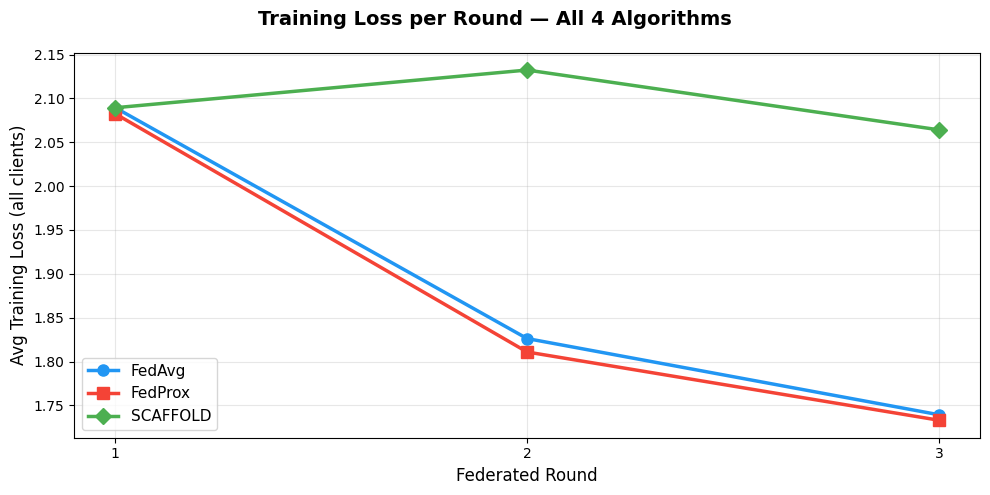

Saved: all_algo_train_loss.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Training Loss per Round — All 4 Algorithms",
             fontsize=14, fontweight="bold")

for algo in ALL_ALGORITHMS:
    avg_losses = [np.mean(round_losses[algo][r]) for r in range(TOTAL_ROUNDS)]
    ax.plot(rounds, avg_losses,
            color=COLORS[algo], marker=MARKERS[algo],
            linewidth=2.5, markersize=8, label=algo)

ax.set_xlabel("Federated Round", fontsize=12)
ax.set_ylabel("Avg Training Loss (all clients)", fontsize=12)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend(fontsize=11, loc="best")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "all_algo_train_loss.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: all_algo_train_loss.png")


## 5. Final Validation Loss Bar Chart (All 4 Algorithms)

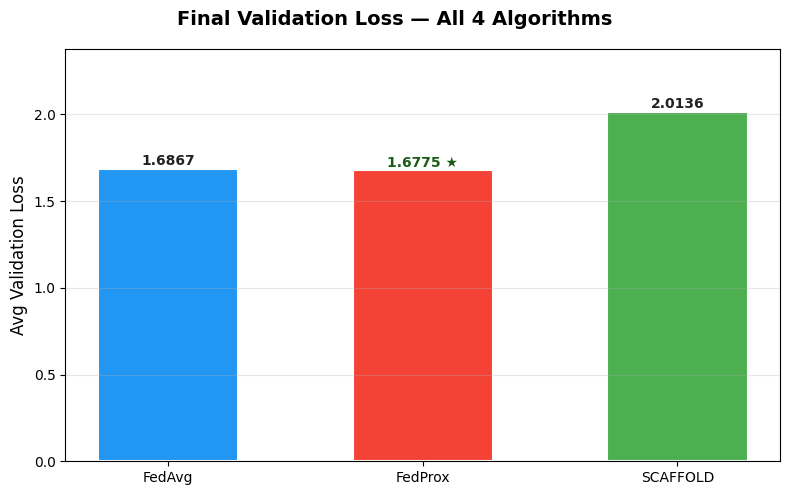

Saved: all_algo_val_loss.png


In [9]:
avg_val = [np.mean(val_losses[a]) for a in ALL_ALGORITHMS]

fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("Final Validation Loss — All 4 Algorithms",
             fontsize=14, fontweight="bold")

bars = ax.bar(ALL_ALGORITHMS, avg_val,
              color=[COLORS[a] for a in ALL_ALGORITHMS],
              edgecolor="white", linewidth=1.5, width=0.55)

best_idx = int(np.argmin(avg_val))
for idx, (bar, val) in enumerate(zip(bars, avg_val)):
    label = f"{val:.4f}" + (" ★" if idx == best_idx else "")
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            label, ha="center", va="bottom",
            fontsize=10, fontweight="bold",
            color=("#222222" if idx != best_idx else "#1a5c1a"))

ax.set_ylabel("Avg Validation Loss", fontsize=12)
ax.set_ylim(0, max(avg_val) * 1.18)
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "all_algo_val_loss.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: all_algo_val_loss.png")


## 6. Combined Dashboard (Training + Validation side-by-side)

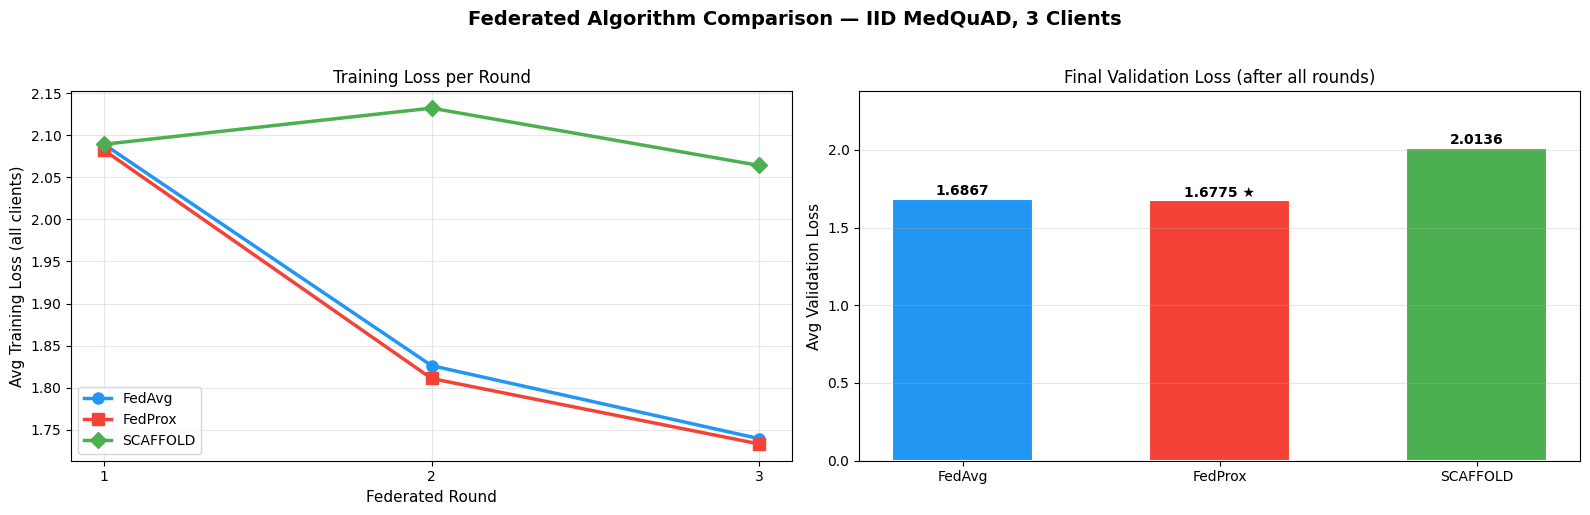

Saved: all_algo_comparison.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Federated Algorithm Comparison — IID MedQuAD, 3 Clients",
             fontsize=14, fontweight="bold", y=1.02)

# ── Left: Training loss per round ──
ax = axes[0]
for algo in ALL_ALGORITHMS:
    avg_losses = [np.mean(round_losses[algo][r]) for r in range(TOTAL_ROUNDS)]
    ax.plot(rounds, avg_losses,
            color=COLORS[algo], marker=MARKERS[algo],
            linewidth=2.5, markersize=8, label=algo)
ax.set_xlabel("Federated Round", fontsize=11)
ax.set_ylabel("Avg Training Loss (all clients)", fontsize=11)
ax.set_title("Training Loss per Round", fontsize=12)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ── Right: Final validation loss ──
ax = axes[1]
bars = ax.bar(ALL_ALGORITHMS, avg_val,
              color=[COLORS[a] for a in ALL_ALGORITHMS],
              edgecolor="white", linewidth=1.5, width=0.55)
for idx, (bar, val) in enumerate(zip(bars, avg_val)):
    label = f"{val:.4f}" + (" ★" if idx == best_idx else "")
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            label, ha="center", va="bottom",
            fontsize=10, fontweight="bold")
ax.set_ylabel("Avg Validation Loss", fontsize=11)
ax.set_title("Final Validation Loss (after all rounds)", fontsize=12)
ax.grid(True, axis="y", alpha=0.3)
ax.set_ylim(0, max(avg_val) * 1.18)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "all_algo_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: all_algo_comparison.png")


## 7. Per-Client Training Loss Curves

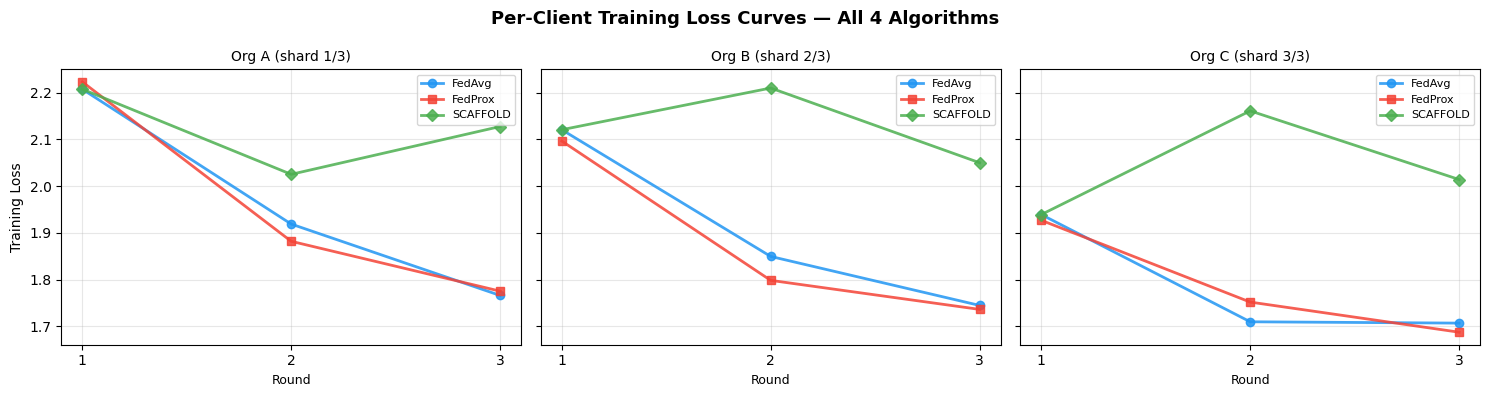

Saved: all_algo_per_client_curves.png


In [11]:
fig, axes = plt.subplots(1, NUM_CLIENTS, figsize=(5 * NUM_CLIENTS, 4), sharey=True)
fig.suptitle("Per-Client Training Loss Curves — All 4 Algorithms",
             fontsize=13, fontweight="bold")

for ci in range(NUM_CLIENTS):
    ax = axes[ci]
    for algo in ALL_ALGORITHMS:
        client_losses = [round_losses[algo][r][ci] for r in range(TOTAL_ROUNDS)]
        ax.plot(rounds, client_losses,
                color=COLORS[algo], marker=MARKERS[algo],
                linewidth=2, markersize=6, label=algo, alpha=0.85)
    ax.set_title(ORG_NAMES[ci], fontsize=10)
    ax.set_xlabel("Round", fontsize=9)
    if ci == 0:
        ax.set_ylabel("Training Loss", fontsize=10)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "all_algo_per_client_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: all_algo_per_client_curves.png")


## 8. Per-Client Validation Loss Heatmap

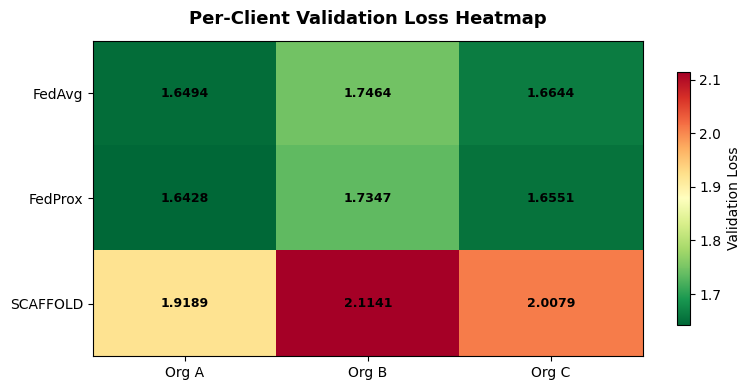

Saved: all_algo_val_heatmap.png


In [12]:
# Build a matrix: rows = algorithms, cols = clients
val_matrix = np.array([val_losses[a] for a in ALL_ALGORITHMS])  # shape (4, num_clients)

fig, ax = plt.subplots(figsize=(max(6, NUM_CLIENTS * 2 + 2), len(ALL_ALGORITHMS) + 1))
im = ax.imshow(val_matrix, aspect="auto", cmap="RdYlGn_r")

ax.set_xticks(range(NUM_CLIENTS))
ax.set_xticklabels([n.split(" (")[0] for n in ORG_NAMES], fontsize=10)
ax.set_yticks(range(len(ALL_ALGORITHMS)))
ax.set_yticklabels(ALL_ALGORITHMS, fontsize=10)
ax.set_title("Per-Client Validation Loss Heatmap", fontsize=13, fontweight="bold", pad=12)

for i in range(len(ALL_ALGORITHMS)):
    for j in range(NUM_CLIENTS):
        ax.text(j, i, f"{val_matrix[i, j]:.4f}",
                ha="center", va="center", fontsize=9, fontweight="bold", color="black")

plt.colorbar(im, ax=ax, shrink=0.8, label="Validation Loss")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "all_algo_val_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: all_algo_val_heatmap.png")


## 9. Export Summary as CSV

In [13]:
summary_rows = []
for algo in ALL_ALGORITHMS:
    row = {"Algorithm": algo}
    for r in range(TOTAL_ROUNDS):
        row[f"Round_{r+1}_avg_train_loss"] = round(np.mean(round_losses[algo][r]), 6)
    for ci in range(NUM_CLIENTS):
        row[f"Val_Client_{ci+1}"] = round(val_losses[algo][ci], 6)
    row["Val_Avg"] = round(np.mean(val_losses[algo]), 6)
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
csv_path = os.path.join(OUTPUT_DIR, "all_algo_summary.csv")
df_summary.to_csv(csv_path, index=False)

print(f"Summary CSV saved to: {csv_path}")
df_summary


Summary CSV saved to: ./fl_outputs\all_algo_summary.csv


,Algorithm,Round_1_avg_train_loss,Round_2_avg_train_loss,Round_3_avg_train_loss,Val_Client_1,Val_Client_2,Val_Client_3,Val_Avg
0,FedAvg,2.089326,1.826188,1.739347,1.649390,1.746399,1.664383,1.686724
1,FedProx,2.082398,1.810878,1.733093,1.642774,1.734734,1.655115,1.677541
2,SCAFFOLD,2.089326,2.132294,2.064141,1.918929,2.114056,2.007869,2.013618


## 10. Interpretation Guide

### FedAvg
- **Best for:** IID data, quick baselines, when simplicity matters
- **Weakness:** Client drift under non-IID data
- **Cost:** Lowest — no extra communication or computation

### FedProx
- **Best for:** Heterogeneous systems, non-IID data
- **Key idea:** Proximal term keeps local models close to global
- **Cost:** Tiny extra compute per batch

### SCAFFOLD
- **Best for:** Non-IID data with strong client drift
- **Key idea:** Control variates cancel the bias each client introduces
- **Cost:** 2× uplink communication; stateful clients

---

### Expected behavior on IID data
With IID data, all algorithms should perform similarly since there is no client drift to correct.
Differences become more pronounced with **non-IID data** where SCAFFOLD and FedProx have a significant advantage.

The ★ marker in the bar chart indicates the best-performing algorithm by average validation loss.
